In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sklearn

In [2]:
pca_df = pd.read_csv(
    "../music_rec/pca_train.csv"
)

In [3]:
from sklearn.cluster import KMeans

In [4]:
X_pca = pca_df.values

inertia = []

k_values = range(2, 11)

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    kmeans.fit(X_pca)

    inertia.append(kmeans.inertia_)

Here, the X_pca variable is defined as the PCA-transformed feature matrix in order to turn it from a DataFrame into a Numpy array for the purpose of clustering, then a k-means fit is performed to group songs in PCA space. Inertia has been measured as well to dtermine how tightly the clusters are grouped together.

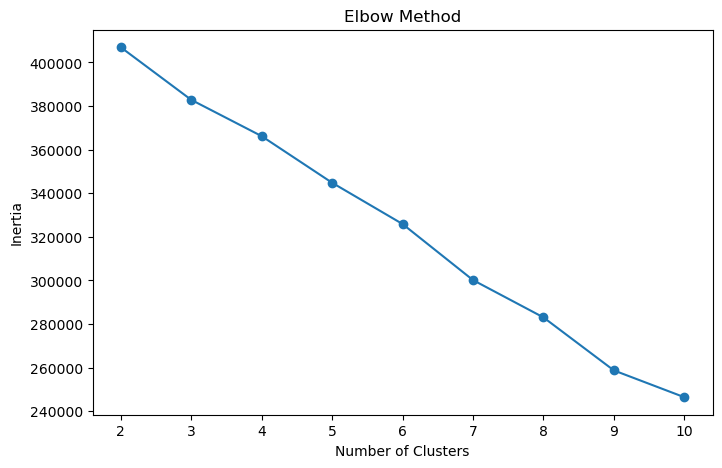

In [5]:
plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    inertia,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.show()

The elbow method reveals the increase of clusters matches a gradual decline in inertia; due to its descent lacking any notable sharp downturn trends, the result could be considered consistent with the dataset as it's been understood up to this point. The fact that the elbow is soft is not a problem here, a reasonable k simply has to be selected from here.

In [6]:
from sklearn.metrics import silhouette_score
scores = []
k_values = range(2, 11)

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    labels = kmeans.fit_predict(X_pca)

    score = silhouette_score(
        X_pca,
        labels
    )

    scores.append(score)

Creating clusters, applying cluster labels with k-means, and then obtaining and storing the sillhouette scores for each k.

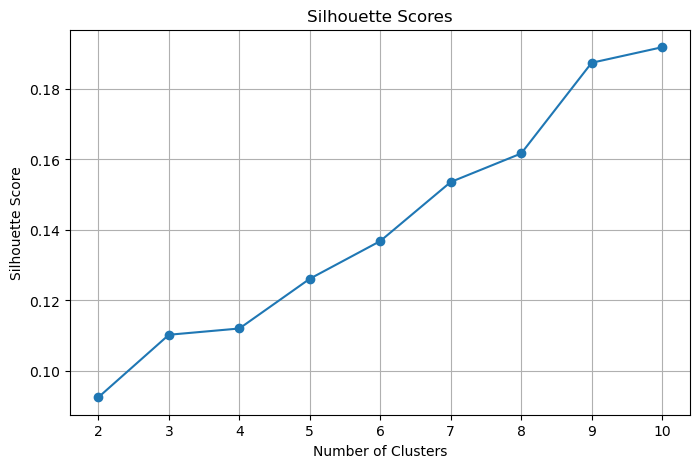

In [7]:
plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    scores,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")

plt.title("Silhouette Scores")

plt.grid(True)

plt.show()

The maximum silhouette score being around .2 is a good sign for this kind of database, and is consistent with prior EDA conclusions about the dataset's continuous thematic gradients. The starker than usal increase from 8 to 9 is of particular interest here, so 8 has be selected for the k value. A moderate cluster count was chosen in order to balance cluster separation and interpretability.

In [8]:
final_k = 8

kmeans = KMeans(
    n_clusters=final_k,
    random_state=42
)

clusters = kmeans.fit_predict(X_pca)

Songs have now been given cluster labels.

In [9]:
pca_df['cluster'] = clusters

Songs now belong to groups by adding the numerical cluster labels to the DataFrame.

In [26]:
pca_df.to_csv(
    "cluster_train.csv",
    index=False
)

Newly saved file.

In [10]:
cluster_summary = pca_df.groupby(
    'cluster'
).mean(numeric_only=True)

cluster_summary

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14
cluster,,,,,,,,,,,,,,
0,-0.608207,0.533564,-0.189963,1.738937,0.110429,0.125004,0.113168,-0.105301,-0.068705,-0.189550,0.055400,0.016367,0.348084,-0.025610
1,2.230657,-0.758963,0.233725,0.202460,0.450254,0.010278,-0.543445,-0.084505,0.030259,-0.222537,0.224690,-0.322117,-0.264639,-0.149496
2,-0.781981,0.129558,1.799997,-0.692286,0.396321,-0.771369,-0.570225,0.428926,-1.575576,-0.295813,-0.132579,0.380718,0.591243,0.570272
3,-0.268608,0.379420,-0.802866,-0.740357,0.036948,-0.124430,0.018848,-0.441538,0.058147,0.001854,0.082667,0.013084,0.116255,-0.101301
4,-1.653779,-0.838529,0.552217,-0.052033,-0.165420,0.265287,-1.542323,0.293145,1.874165,0.295514,-0.385789,0.061547,-0.868766,0.771578
5,-0.336237,-1.159782,-0.217608,0.438027,-1.814076,-0.254546,0.201728,0.078891,-1.565420,3.445661,0.800869,-0.804064,-0.763015,-0.128180
6,-0.369938,-0.908546,0.163329,-0.384722,-1.506397,1.175199,1.288281,0.867528,-0.304995,-1.385467,0.154832,0.025541,-0.621514,-0.070363
7,0.816944,0.587860,0.775558,-0.291615,0.525267,-0.166612,1.373528,0.660690,0.841112,0.835343,-0.875752,0.363492,0.230074,-0.385682


In [11]:

X_pca = pca_df.drop(columns=['cluster'], errors='ignore').values

kmeans = KMeans(n_clusters=8, random_state=42)
clusters = kmeans.fit_predict(X_pca)


pca_df['cluster'] = clusters

clean_df = pd.read_csv("../music_rec/cleaned_train.csv")

clean_df['cluster'] = clusters

cluster_summary = clean_df.groupby('cluster').mean(numeric_only=True)

cluster_summary.T

cluster,0,1,2,3,4,5,6,7
Unnamed: 0,42132.090837,49648.480190,39019.249486,43707.823504,35886.258450,41430.387571,41451.495435,40812.933188
release_date,1988.533596,1999.988680,1982.325935,1992.253618,1978.093084,1987.468927,1988.309467,1988.506987
len,60.417143,122.222323,61.808467,64.928062,51.133125,67.809040,63.813551,79.562882
dating,0.017284,0.021942,0.023720,0.019980,0.029418,0.029550,0.032578,0.009117
violence,0.051042,0.064902,0.036968,0.228394,0.030113,0.050831,0.047388,0.177124
world/life,0.427018,0.045752,0.047303,0.048682,0.066371,0.061268,0.049908,0.091986
night/time,0.031521,0.025659,0.031284,0.030611,0.037276,0.041424,0.389360,0.032889
shake the audience,0.015106,0.029126,0.014307,0.015652,0.014408,0.019386,0.019050,0.010691
family/gospel,0.015656,0.018392,0.021716,0.016108,0.016487,0.018039,0.017895,0.015664
romantic,0.029251,0.013465,0.026769,0.025089,0.385152,0.029981,0.029804,0.020094


Cluster 0: Pro-Social World-Inclined Cluster

Cluster 1: Angry Provocative Cluster

Cluster 2: Music-Focused Cluster

Cluster 3: Emotionally Intense Cluster

Cluster 4: Love Song Cluster

Cluster 5: Expressive Feelings Cluster

Cluster 6: Nightlife/Party Vibes Cluster

Cluster 7: Journey & Travel Songs Cluster

Interpretation:

The clustering process revealed multiple semantically interpretable lyrical groupings. Many clusters demonstrated strong specialization around dominant thematic dimensions such as love, obscenity, nightlife, music-focused content, emotional expression, or pro social movement-oriented lyrics. These findings support earlier EDA observations suggesting that songs tend to weakly express most themes while strongly activating a smaller subset of semantic dimensions.


In [33]:
import joblib

joblib.dump(kmeans, "kmeans_model.pkl")

['kmeans_model.pkl']

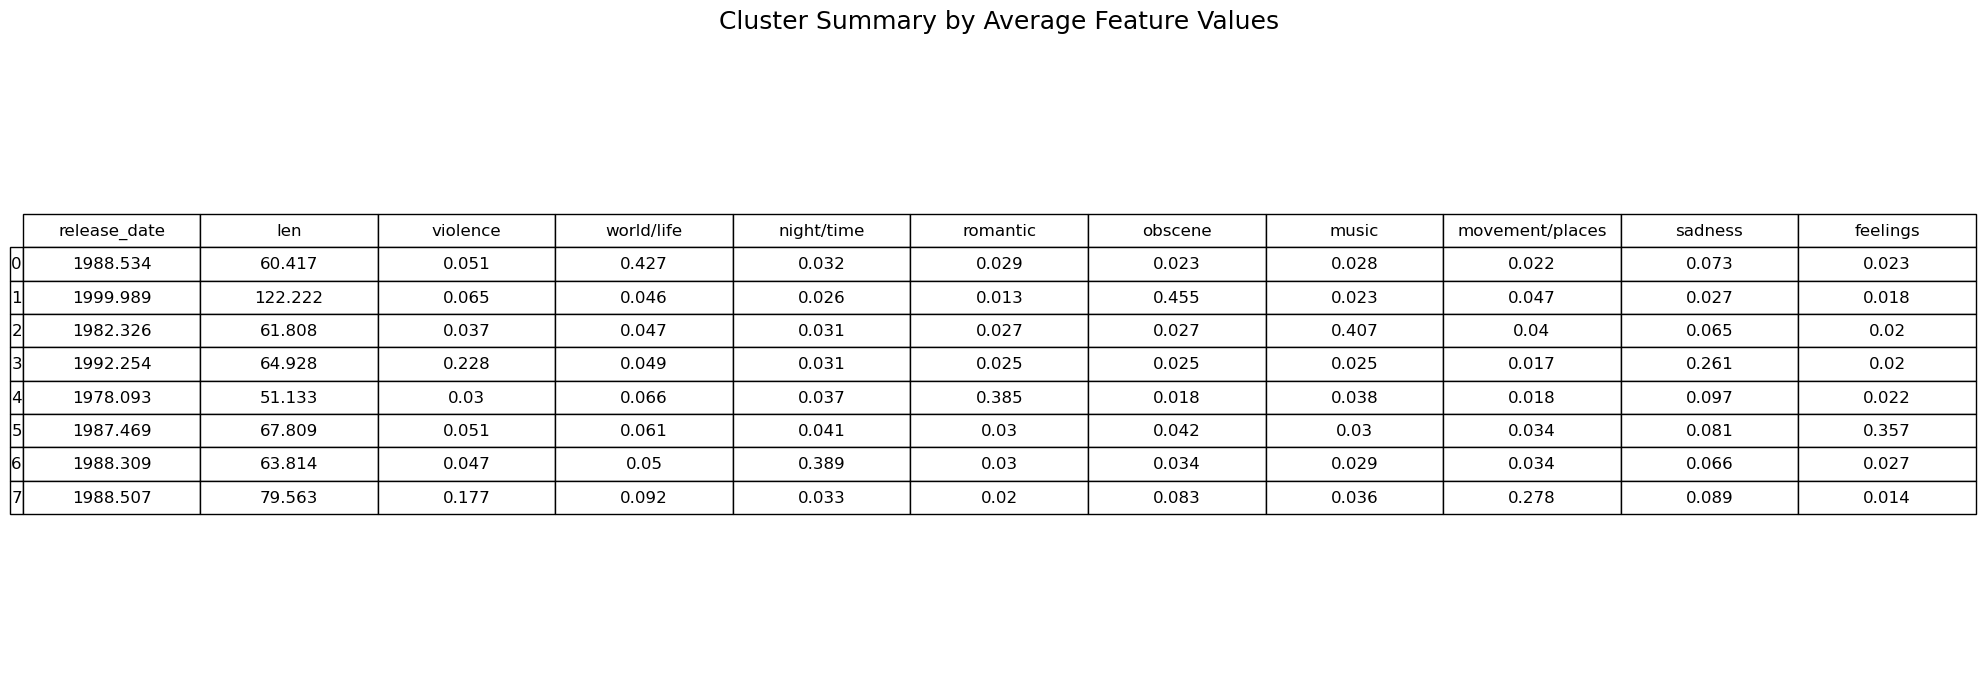

In [19]:
import os

important_cols = [
    "release_date",
    "len",
    "violence",
    "world/life",
    "night/time",
    "romantic",
    "obscene",
    "music",
    "movement/places",
    "sadness",
    "feelings"
]

cluster_summary_small = cluster_summary.loc[:, important_cols].round(3)

fig, ax = plt.subplots(figsize=(18, 8))
ax.axis("off")

table = ax.table(
    cellText=cluster_summary_small.values,
    colLabels=cluster_summary_small.columns,
    rowLabels=cluster_summary_small.index,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.4, 2.0)

plt.title("Cluster Summary by Average Feature Values", fontsize=18, pad=20)

plt.savefig(
    "cluster_summary.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()